In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import class_weight

from keras.models import Sequential
from keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    BatchNormalization, Flatten, Activation
)
from keras.optimizers import Adam
from keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
IMG_SIZE   = 48
BATCH_SIZE = 64
EPOCHS     = 80
TRAIN_DIR  = 'binary_data/train'
TEST_DIR   = 'binary_data/test'
os.makedirs('models', exist_ok=True)

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    subset='validation'
)

print("Class indices:", train_gen.class_indices)
# Keras alphabetical: {'irritated': 0, 'neutral': 1}

Found 22968 images belonging to 2 classes.
Found 5741 images belonging to 2 classes.
Class indices: {'irritated': 0, 'neutral': 1}


In [12]:
def build_binary_cnn():
    model = Sequential()
    
    # Block 1: 32 filters
    model.add(Conv2D(32, (3,3), padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)))
    model.add(BatchNormalization()); model.add(Activation('relu'))
    model.add(Conv2D(32, (3,3), padding='same'))
    model.add(BatchNormalization()); model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2))); model.add(Dropout(0.25))
    
    # Block 2: 64 filters
    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(BatchNormalization()); model.add(Activation('relu'))
    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(BatchNormalization()); model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2))); model.add(Dropout(0.25))
    
    # Block 3: 128 filters
    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(BatchNormalization()); model.add(Activation('relu'))
    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(BatchNormalization()); model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2))); model.add(Dropout(0.35))
    
    # Block 4: 256 filters
    model.add(Conv2D(256, (3,3), padding='same'))
    model.add(BatchNormalization()); model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2))); model.add(Dropout(0.35))
    
    # Fully connected layers
    model.add(Flatten())
    model.add(Dense(512)); model.add(BatchNormalization())
    model.add(Activation('relu')); model.add(Dropout(0.5))
    
    model.add(Dense(256)); model.add(BatchNormalization())
    model.add(Activation('relu')); model.add(Dropout(0.3))
    
    # Binary output: 1 neuron, sigmoid
    model.add(Dense(1, activation='sigmoid'))
    
    return model

model = build_binary_cnn()
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall', 'AUC']
)
model.summary()


/home/lenovo/ml/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 12, 12, 128)    │             

 Total params: 1,899,233 (7.24 MB)

 Trainable params: 1,896,289 (7.23 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [13]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        'models/binary_emotion_model.h5',
        monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]


In [14]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))

In [15]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/80


I0000 00:00:1773530920.004868  138853 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20241__.117


228/359 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - AUC: 0.5237 - Precision: 0.4487 - Recall: 0.5219 - accuracy: 0.5242 - loss: 0.7934

I0000 00:00:1773530937.838162  138856 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20241__.117


358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - AUC: 0.5290 - Precision: 0.4507 - Recall: 0.5339 - accuracy: 0.5253 - loss: 0.7777
Epoch 1: val_accuracy improved from None to 0.42432, saving model to models/binary_emotion_model.h5


...


Epoch 15: finished saving model to models/binary_emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - AUC: 0.8670 - Precision: 0.7381 - Recall: 0.7654 - accuracy: 0.7853 - loss: 0.4544 - val_AUC: 0.9137 - val_Precision: 0.7351 - val_Recall: 0.8805 - val_accuracy: 0.8147 - val_loss: 0.4158 - learning_rate: 5.0000e-04
Epoch 16/80
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - AUC: 0.8698 - Precision: 0.7350 - Recall: 0.7727 - accuracy: 0.7878 - loss: 0.4487
Epoch 16: val_accuracy improved from 0.81467 to 0.82460, saving model to models/binary_emotion_model.h5



Epoch 16: finished saving model to models/binary_emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - AUC: 0.8711 - Precision: 0.7415 - Recall: 0.7736 - accuracy: 0.7895 - loss: 0.4479 - val_AUC: 0.9259 - val_Precision: 0.7453 - val_Recall: 0.8912 - val_accuracy: 0.8246 - val_loss: 0.3968 - learning_rate: 5.0000e-04
Epoch 17/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - AUC: 0.8777 - Precision: 0.7425 - Recall: 0.7781 - accuracy: 0.7924 - loss: 0.4368
Epoch 17: val_accuracy improved from 0.82460 to 0.83156, saving model to models/binary_emotion_model.h5



Epoch 17: finished saving model to models/binary_emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - AUC: 0.8777 - Precision: 0.7495 - Recall: 0.7762 - accuracy: 0.7950 - loss: 0.4370 - val_AUC: 0.9083 - val_Precision: 0.7846 - val_Recall: 0.8313 - val_accuracy: 0.8316 - val_loss: 0.3928 - learning_rate: 5.0000e-04
Epoch 18/80
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - AUC: 0.8836 - Precision: 0.7560 - Recall: 0.7833 - accuracy: 0.8031 - loss: 0.4275
Epoch 18: val_accuracy did not improve from 0.83156
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - AUC: 0.8803 - Precision: 0.7544 - Recall: 0.7822 - accuracy: 0.7995 - loss: 0.4335 - val_AUC: 0.9182 - val_Precision: 0.6141 - val_Recall: 0.9479 - val_accuracy: 0.7251 - val_loss: 0.5222 - learning_rate: 5.0000e-04
Epoch 19/80
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - AUC: 0.8793 - Precision: 0.7490 - Recall: 0.7746 - accuracy: 0.7932 - loss: 0.4349
Epoch 19: val_accuracy did not improve from 0.83156
359/359 ━━━━━━━━━━━━━━━━━━━━ 


Epoch 22: finished saving model to models/binary_emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - AUC: 0.8844 - Precision: 0.7544 - Recall: 0.7886 - accuracy: 0.8014 - loss: 0.4261 - val_AUC: 0.9183 - val_Precision: 0.7700 - val_Recall: 0.8633 - val_accuracy: 0.8326 - val_loss: 0.3789 - learning_rate: 5.0000e-04
Epoch 23/80
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - AUC: 0.8862 - Precision: 0.7560 - Recall: 0.7997 - accuracy: 0.8048 - loss: 0.4240
Epoch 23: val_accuracy did not improve from 0.83261
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - AUC: 0.8873 - Precision: 0.7571 - Recall: 0.7961 - accuracy: 0.8051 - loss: 0.4217 - val_AUC: 0.9210 - val_Precision: 0.6530 - val_Recall: 0.9323 - val_accuracy: 0.7610 - val_loss: 0.5010 - learning_rate: 5.0000e-04
Epoch 24/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - AUC: 0.8874 - Precision: 0.7549 - Recall: 0.7921 - accuracy: 0.8034 - loss: 0.4207
Epoch 24: val_accuracy did not improve from 0.83261
359/359 ━━━━━━━━━━━━━━━━━━━━ 


Epoch 27: finished saving model to models/binary_emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - AUC: 0.8913 - Precision: 0.7633 - Recall: 0.7953 - accuracy: 0.8085 - loss: 0.4139 - val_AUC: 0.9298 - val_Precision: 0.7916 - val_Recall: 0.8732 - val_accuracy: 0.8486 - val_loss: 0.3508 - learning_rate: 5.0000e-04
Epoch 28/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - AUC: 0.8928 - Precision: 0.7648 - Recall: 0.7995 - accuracy: 0.8115 - loss: 0.4114
Epoch 28: val_accuracy did not improve from 0.84863
359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - AUC: 0.8915 - Precision: 0.7581 - Recall: 0.7991 - accuracy: 0.8066 - loss: 0.4142 - val_AUC: 0.9286 - val_Precision: 0.6827 - val_Recall: 0.9290 - val_accuracy: 0.7866 - val_loss: 0.4407 - learning_rate: 5.0000e-04
Epoch 29/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - AUC: 0.8943 - Precision: 0.7718 - Recall: 0.8011 - accuracy: 0.8167 - loss: 0.4091
Epoch 29: val_accuracy did not improve from 0.84863
359/359 ━━━━━━━━━━━━━━━━━━━━ 


✅ Training complete! Model saved to models/binary_emotion_model.h5
   Training curves saved to models/training_curves.png


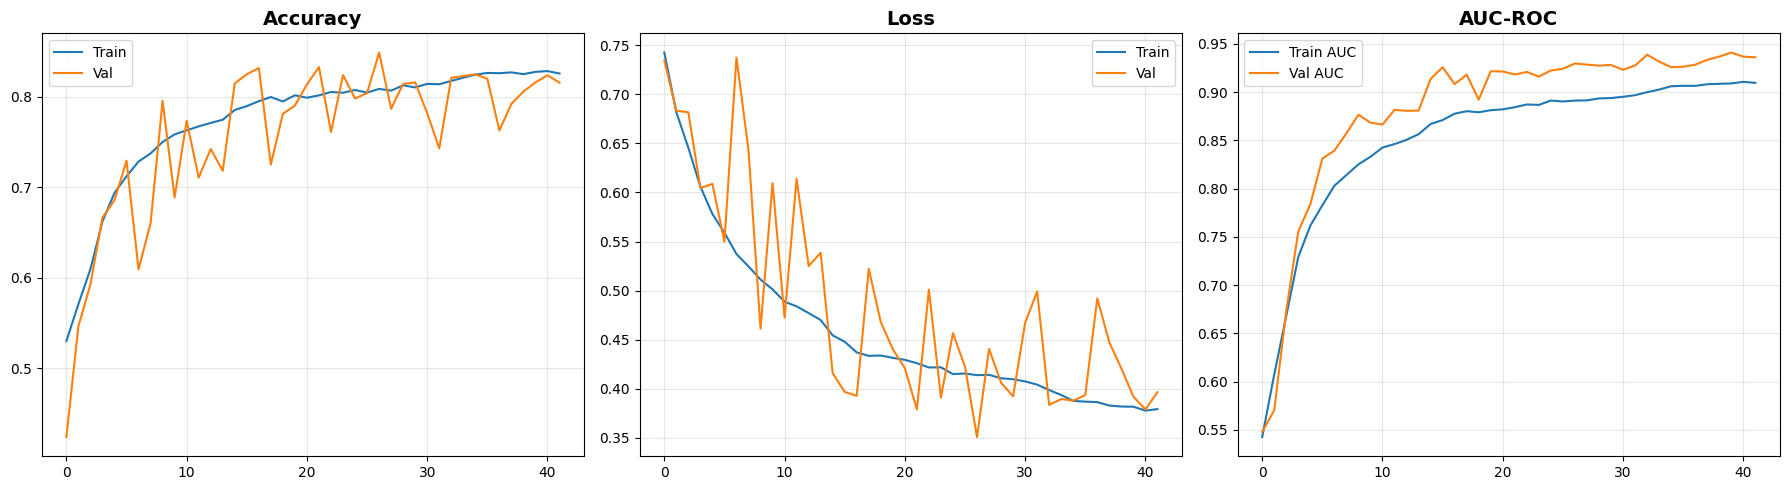

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss', fontsize=14, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history.history['AUC'],     label='Train AUC')
axes[2].plot(history.history['val_AUC'], label='Val AUC')
axes[2].set_title('AUC-ROC', fontsize=14, fontweight='bold')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/training_curves.png', dpi=150, bbox_inches='tight')
print("\n✅ Training complete! Model saved to models/binary_emotion_model.h5")
print("   Training curves saved to models/training_curves.png")